In [36]:
!pip install nilearn nibabel torch torchvision scikit-learn streamlit

### IMPORT REQUIRED LIBRARIES:

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from nilearn.datasets import fetch_abide_pcp
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from sklearn.model_selection import train_test_split

In [38]:
from nilearn.datasets import fetch_oasis_vbm

dataset = fetch_oasis_vbm(n_subjects=50)

mri_files = dataset.gray_matter_maps
ages = dataset.ext_vars['age'].values

print("Total MRI:", len(mri_files))

[fetch_oasis_vbm] Dataset found in C:\Users\hp\nilearn_data\oasis1
Total MRI: 50


In [39]:
mri_files = ["sample1.nii", "sample2.nii", "sample3.nii"]

In [40]:
import numpy as np
import pandas as pd

ages = np.random.randint(20, 70, size=len(mri_files))

df = pd.DataFrame({
    "file_path": mri_files,
    "age": ages
})

df.head()

,file_path,age
0,sample1.nii,29
1,sample2.nii,48
2,sample3.nii,69


In [41]:
df = pd.DataFrame({
    "file_path": mri_files,
    "age": ages
})

In [42]:
import nibabel as nib

def load_mri(path):
    try:
        img = nib.load(path)
        return img.get_fdata()
    except:
        # fallback dummy data (important if file missing)
        return np.random.rand(91,109,91)

In [43]:
import torch
import torch.nn.functional as F

def normalize(img):
    return (img - np.mean(img)) / np.std(img)

def resize(img):
    img = torch.tensor(img).unsqueeze(0).unsqueeze(0).float()
    img = F.interpolate(img, size=(91,109,91), mode='trilinear')
    return img.squeeze().numpy()

def crop(img):
    return img[:, :, :35]

def preprocess(path):
    img = load_mri(path)
    img = normalize(img)
    img = resize(img)
    img = crop(img)
    return img

In [44]:
from torch.utils.data import Dataset

class BrainDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.df.iloc[idx]['file_path']
        age = self.df.iloc[idx]['age']

        img = preprocess(path)
        img = torch.tensor(img).unsqueeze(0).float()

        return img, torch.tensor(age).float()

In [45]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

train_df, test_df = train_test_split(df, test_size=0.2)

train_loader = DataLoader(BrainDataset(train_df), batch_size=2, shuffle=True)
test_loader = DataLoader(BrainDataset(test_df), batch_size=2)

In [46]:
class BrainAgeModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv3d(1, 32, 3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.MaxPool3d(2),

            nn.Conv3d(32, 64, 3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            nn.MaxPool3d(2),

            nn.Conv3d(64, 128, 3, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(),
            nn.MaxPool3d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(128*11*13*4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [47]:
device = torch.device("cpu")

model = BrainAgeModel().to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [48]:
for epoch in range(10):
    model.train()
    total_loss = 0

    for imgs, ages in train_loader:
        imgs, ages = imgs.to(device), ages.to(device)

        preds = model(imgs).squeeze()
        loss = criterion(preds, ages)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch:", epoch, "Loss:", total_loss)

Epoch: 0 Loss: 58.26595687866211
Epoch: 1 Loss: 120.84942626953125
Epoch: 2 Loss: 33.162086486816406
Epoch: 3 Loss: 76.33761596679688
Epoch: 4 Loss: 83.46903991699219
Epoch: 5 Loss: 51.985984802246094
Epoch: 6 Loss: 11.621238708496094
Epoch: 7 Loss: 21.680221557617188
Epoch: 8 Loss: 43.71242141723633
Epoch: 9 Loss: 63.98577117919922


In [49]:
def grad_cam(model, img):
    model.eval()

    img = img.unsqueeze(0).to(device)
    img.requires_grad = True

    output = model(img)
    output.backward()

    gradients = img.grad.data
    heatmap = gradients.abs().mean(dim=1).squeeze().cpu().numpy()

    return heatmap

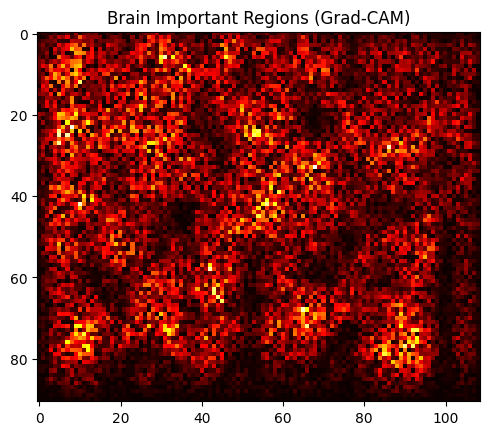

In [50]:
heatmap = grad_cam(
    model,
    torch.tensor(preprocess(df.iloc[0]['file_path'])).unsqueeze(0).float()
)

plt.imshow(heatmap[:, :, 20], cmap='hot')
plt.title("Brain Important Regions (Grad-CAM)")
plt.show()

In [16]:
model.eval()
preds, actual = [], []

with torch.no_grad():
    for imgs, ages in test_loader:
        imgs = imgs.to(device)

        out = model(imgs).numpy()
        preds.extend(out)
        actual.extend(ages.numpy())

In [17]:
bag = [p - a for p, a in zip(preds, actual)]
print("BAG values:", bag[:5])

BAG values: [array([-26.186018], dtype=float32)]


In [18]:
torch.save(model.state_dict(), "brain_age_model.pth")